# Graph Neural Networks for solving PDEs

- In this tutorial, we will learn how to use Graph Neural Networks (GNNs) to solve Partial Differential Equations (PDEs). We will test out how Graph Convolutional Networks (GCNs) and Graph Attention Networks (GATs) work in practice.

- We will test GNNs on data from the two-dimensional Allen–Cahn equation. Despite the data being defined on a uniform grid, GNNs remain applicable, as they generalize naturally to both structured and unstructured domains.

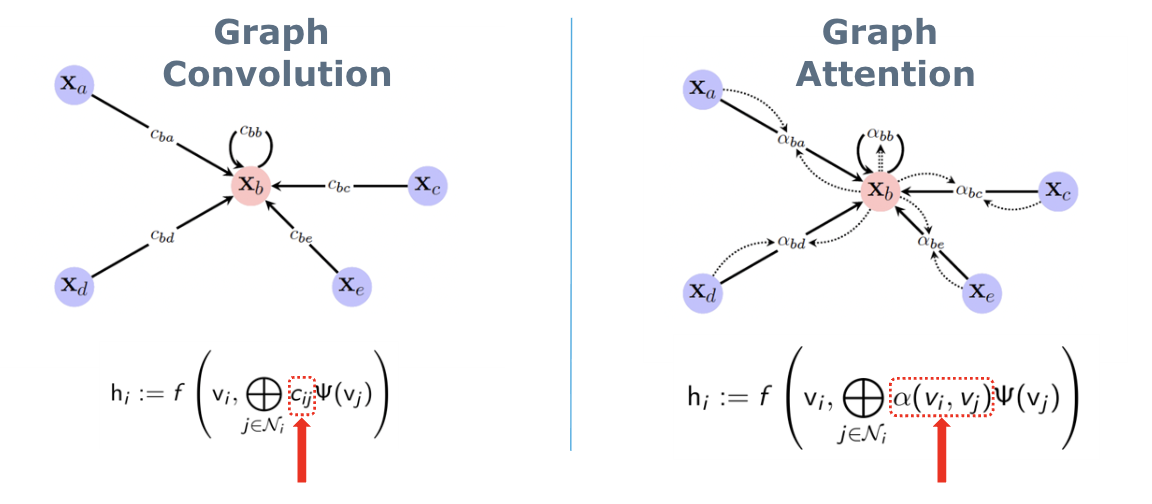

- A model is defined as a sequene of graph convolution/attention layers:

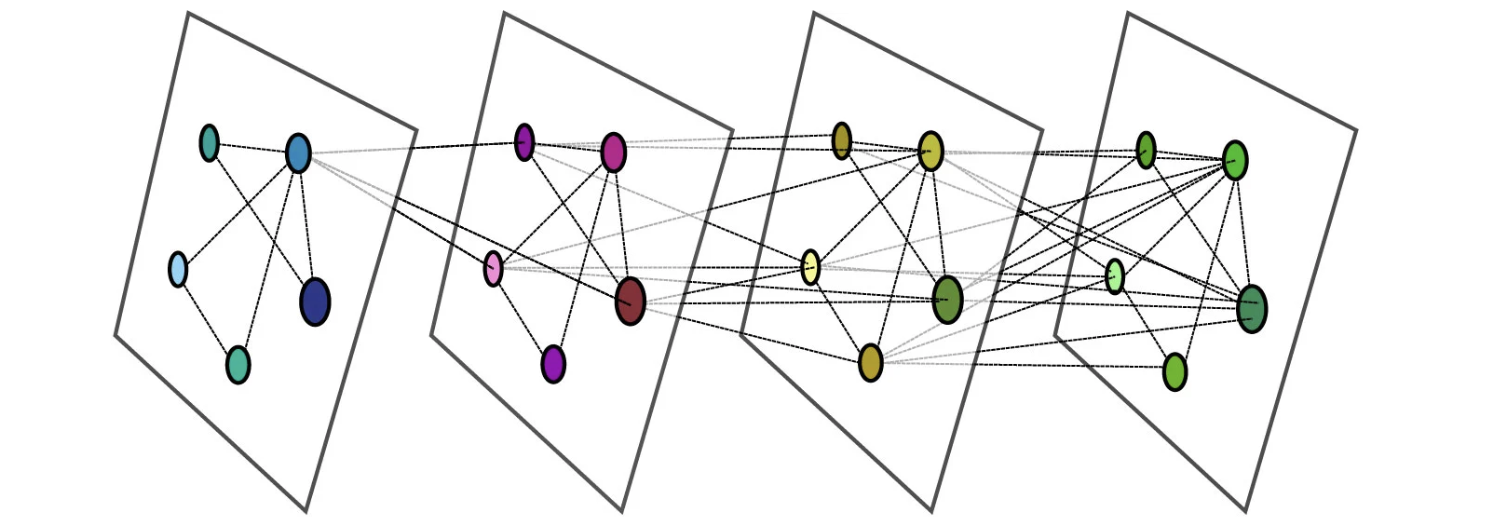

**GCN does `L` layers of message passing. Each layer:**

1. For each node, collects information from its neighbors (including itself).
2. Aggregates neighbors using a degree-normalized sum/mean.
3. Applies a learned linear transform (inside `GCNConv`).
4. Applies a nonlinearity (except in the last layer).


**GAT learns attention coefficients on edges (instead of fixed averaging). Each layer:**

1. Computes a message from neighbor $j$ to node $i$.
2. Computes a learned "importance" score $e_{ij}$ based on node features.
3. Normalizes scores across neighbors of $i$ with softmax to get $\alpha_{ij}$.
4. Aggregates neighbor messages:

$$
h_i' = \sum_{j \in \mathcal{N}(i)} \alpha_{ij} W h_j
$$


<br>
<br>

----
<br>

1. Download the data and the models from [THIS LINK](https://drive.google.com/drive/folders/1_XQJM6zi6KxGq88taWXDijgsrkJynjpn?usp=sharing)

2. Install torch_geometric:

In [ ]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.0 MB/s eta 0:00:00


<br>
<br>

----

<br>

In [ ]:
import torch.nn as nn
import torch

import random
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

from torch.optim import AdamW
from models import init_gnn_model
import torch_geometric
from torch_geometric.data import Data

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

## PDEs

Solutions of PDEs are operators that act as mappings between function spaces. They take initial conditions, boundary conditions, and source terms as inputs and yield the PDE solution as output. For instance, in fluid dynamics, the solution operator can compute the flow profile at a specific future time (e.g. $T = 1$) given the initial flow and boundary conditions


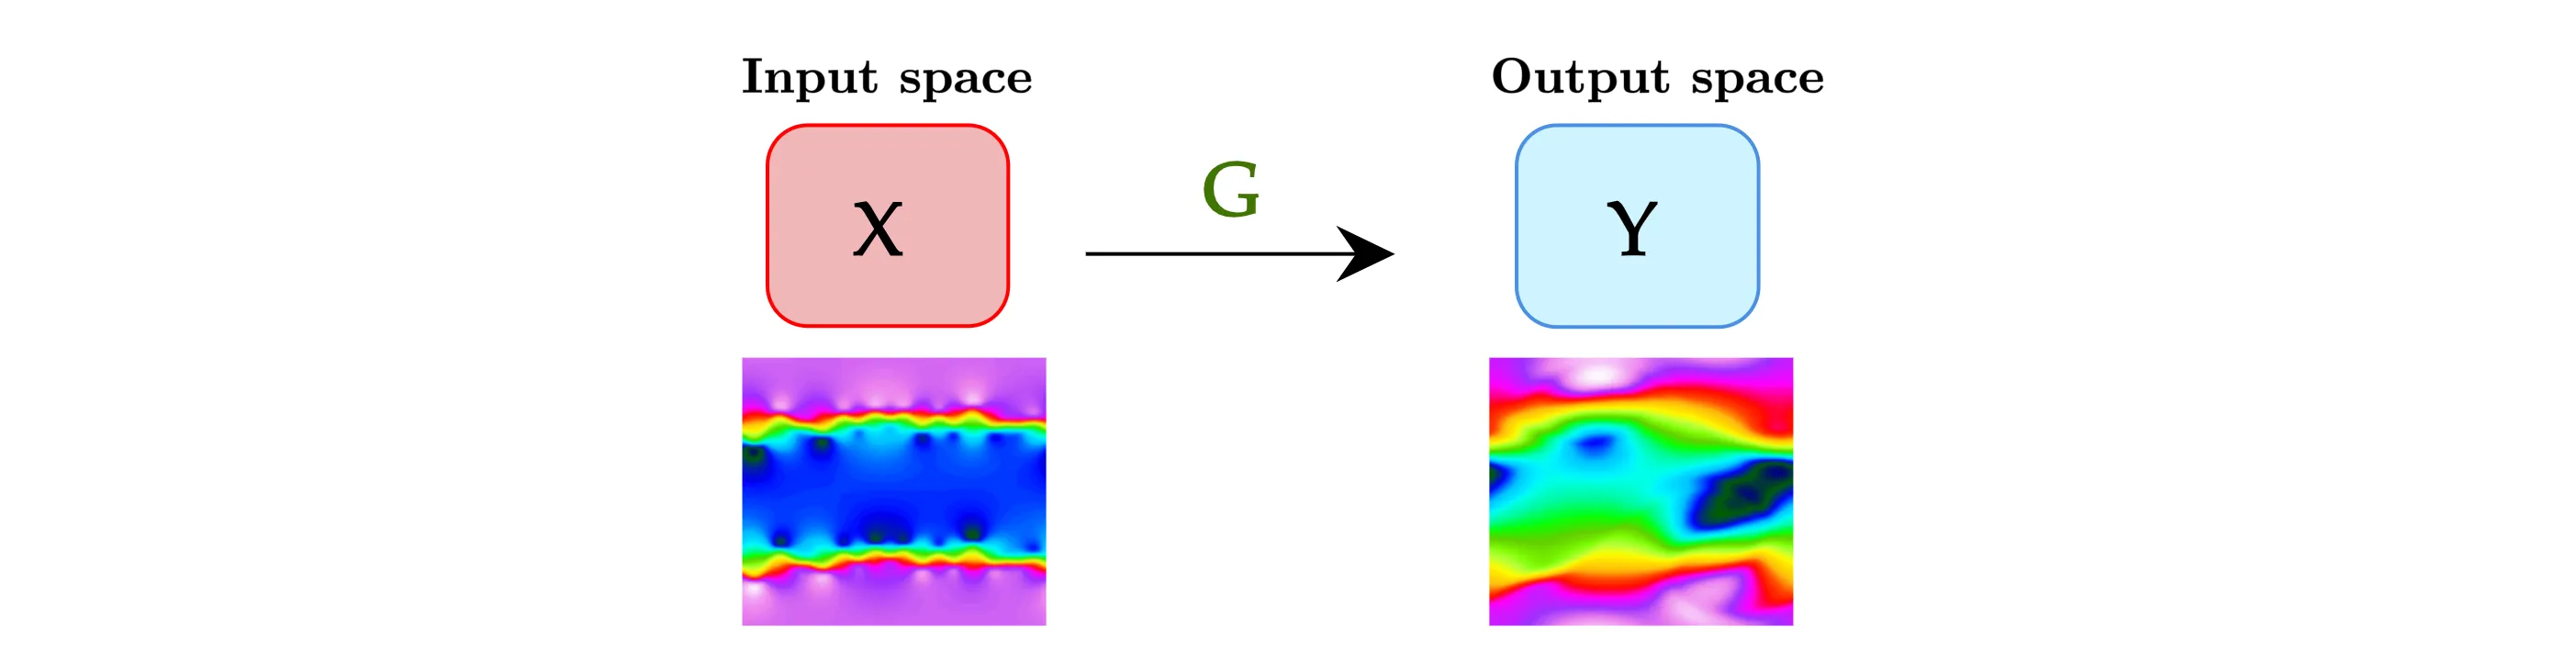

We consider the **Allen–Cahn equation**, a classical nonlinear reaction–diffusion PDE:

## $$u_t = \Delta u - \varepsilon^2\, u\,(u^2 - 1), \qquad u:\mathbb{R}^d \times \mathbb{R}_{>0}\to\mathbb{R}.$$

It consists of two competing effects:

- **Diffusion**: the Laplacian term $$\Delta u$$ smooths the solution in space by spreading out variations.
- **Reaction (nonlinearity)**: the term $$-\varepsilon^2\,u(u^2-1)$$ drives the field toward the stable phases $u \approx \pm 1$ (and makes $u=0$ unstable).  
  This creates sharp transition regions (“interfaces”) separating domains where the solution is close to $+1$ or $-1$.

The parameter $\varepsilon$ controls the **interface thickness** and the strength of the reaction: smaller $\varepsilon$ typically leads to thinner, sharper interfaces.


Operator that we wish to learn is

## $\mathcal{G}: u(\cdot, t = 0) \mapsto  u(\cdot, t = 1)$

In [ ]:
########################
# Dataloader definition:
########################

class AllenCahnDataset(Dataset):
    def __init__(self, which="train", training_samples = 256):

        assert training_samples<=256

        #Default file:
        self.file_data = "AllenCahn_NEW.h5"
        self.reader = h5py.File(self.file_data, 'r')

        #Load normaliation constants:
        self.min_data = self.reader['min_u0'][()]
        self.max_data = self.reader['max_u0'][()]
        self.min_model = self.reader['min_u'][()]
        self.max_model = self.reader['max_u'][()]

        if which == "train":
            self.length = training_samples
            self.start = 0
        elif which == "val":
            self.length = 128
            self.start = 256
        elif which == "test":
            self.length = 128
            self.start = 256+128

        self.reader = h5py.File(self.file_data, 'r')

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        inputs = torch.from_numpy(self.reader['Sample_' + str(index + self.start)]["input"][:]).type(torch.float32).reshape(1, 64, 64)
        labels = torch.from_numpy(self.reader['Sample_' + str(index + self.start)]["output"][:]).type(torch.float32).reshape(1, 64, 64)

        inputs = (inputs - self.min_data)/(self.max_data - self.min_data)
        labels = (labels - self.min_model)/(self.max_model - self.min_model)

        return inputs, labels

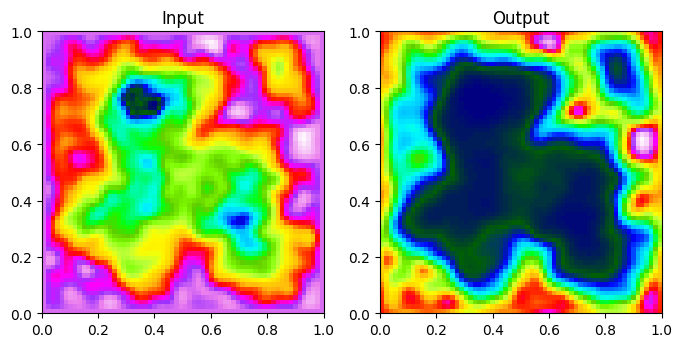

In [ ]:
training_samples = 256
batch_size = 16

'''
  Define the training and validation data loaders:
'''
train_dataset = AllenCahnDataset(which="train", training_samples = training_samples)
val_dataset = AllenCahnDataset(which="val")

train_loader  = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size = batch_size, shuffle=False)


input, output = next(iter(train_loader))
input = input[0,0].numpy()
output = output[0,0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(input, cmap = "gist_ncar", extent=(0,1,0,1),)
axes[0].set_title("Input")
axes[1].imshow(output, cmap = "gist_ncar", extent=(0,1,0,1),)
axes[1].set_title("Output")
plt.show()

## Creation of the graph

- To apply a GNN, we first define an underlying graph structure. In this case, each pixel is connected to its four immediate neighbors (up, down, left, and right). Note that this is just one of the choices. One can define different graph structures from the underlying data.

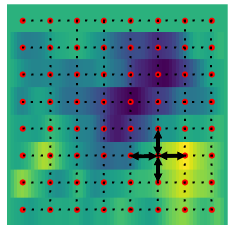

In [ ]:
def create_grid_graph(height=64, width=64):
    """
    Create a grid graph structure from image dimensions.
    Each pixel is a node, connected to its 4 neighbors (up, down, left, right).

    Returns:
        edge_index: torch.LongTensor of shape [2, num_edges]
    """
    edges = []

    # Create edges for grid connectivity (4-neighbors)
    for i in range(height):
        for j in range(width):
            node_idx = i * width + j

            # Connect to right neighbor
            if j < width - 1:
                edges.append([node_idx, node_idx + 1])
                edges.append([node_idx + 1, node_idx])

            # Connect to bottom neighbor
            if i < height - 1:
                edges.append([node_idx, node_idx + width])
                edges.append([node_idx + width, node_idx])

    edge_index = torch.LongTensor(edges).t().contiguous()
    return edge_index


## Defining a model

In [ ]:
class Config:
    def __init__(self):
        self.n_hidden = 128          # hidden dimension
        self.n_layers = 4           # number of GNN layers (for GCN, GAT)
        self.activation = "gelu"    # activation function

        # Model-specific parameters:
        self.num_heads = 4          # for GAT model

# Create the graph structure (this is fixed for all samples)
edge_index = create_grid_graph(64, 64)

config = Config()

# Initialize model using init_gnn_model function
# You can try different models: "gcn", "gat"
model_name = "gat"
model = init_gnn_model(
    model=model_name,
    num_features=1,  # input has 1 channel
    num_classes=1,   # output has 1 channel
    kwargs=config
)

print(f"Model initialized: {model.__class__.__name__}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

Model initialized: GAT
Number of parameters: 34179


## Training a model

In [ ]:
########################
# Training loop:
########################
optimizer = AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0 = 200, eta_min=10**-6)
l = nn.L1Loss()

num_epochs = 20

freq_print = 1
for epoch in range(num_epochs):
    model.train()
    train_mse = 0.0
    for step, (input_batch, output_batch) in enumerate(train_loader):
        # Reshape from [batch, 1, 64, 64] to [batch, 64*64, 1] for graph processing
        batch_size = input_batch.shape[0]
        input_nodes = input_batch.reshape(batch_size, 64*64, 1)
        output_nodes = output_batch.reshape(batch_size, 64*64, 1)

        optimizer.zero_grad()
        output_pred_nodes = model(input_nodes, edge_index)

        # Reshape back for loss computation
        output_pred_batch = output_pred_nodes.reshape(batch_size, 1, 64, 64)

        loss_f = l(output_pred_batch, output_batch) / l(output_batch, torch.zeros_like(output_batch))
        loss_f.backward()
        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(train_loader)

    scheduler.step()
    with torch.no_grad():
        model.eval()
        test_relative_l1 = 0.0
        for step, (input_batch, output_batch) in enumerate(val_loader):
            # Reshape from [batch, 1, 64, 64] to [batch, 64*64, 1]
            batch_size = input_batch.shape[0]
            input_nodes = input_batch.reshape(batch_size, 64*64, 1)
            output_nodes = output_batch.reshape(batch_size, 64*64, 1)

            output_pred_nodes = model(input_nodes, edge_index)
            output_pred_batch = output_pred_nodes.reshape(batch_size, 1, 64, 64)

            loss_f = (torch.mean((abs(output_pred_batch - output_batch))) / torch.mean(abs(output_batch))) * 100
            test_relative_l1 += loss_f.item()
        test_relative_l1 /= len(val_loader)

    if epoch % freq_print == 0: print("## Epoch:", epoch, " ## Train Loss:", train_mse, "## Rel L1 Test Norm:", test_relative_l1, "LR: ", scheduler.get_last_lr())

## Epoch: 0  ## Train Loss: 0.6112969219684601 ## Rel L1 Test Norm: 53.969032764434814 LR:  [0.0009999383779245895]
## Epoch: 1  ## Train Loss: 0.4301252160221338 ## Rel L1 Test Norm: 43.42130994796753 LR:  [0.0009997535269026829]
## Epoch: 2  ## Train Loss: 0.3838231172412634 ## Rel L1 Test Norm: 35.882209062576294 LR:  [0.000999445492543504]
## Epoch: 3  ## Train Loss: 0.28881795704364777 ## Rel L1 Test Norm: 24.864644050598145 LR:  [0.0009990143508499217]
## Epoch: 4  ## Train Loss: 0.2106747254729271 ## Rel L1 Test Norm: 23.662891626358032 LR:  [0.0009984602081996976]
## Epoch: 5  ## Train Loss: 0.20523872785270214 ## Rel L1 Test Norm: 23.09991693496704 LR:  [0.0009977832013192385]
## Epoch: 6  ## Train Loss: 0.20582872815430164 ## Rel L1 Test Norm: 22.76096224784851 LR:  [0.0009969834972498623]


KeyboardInterrupt: 

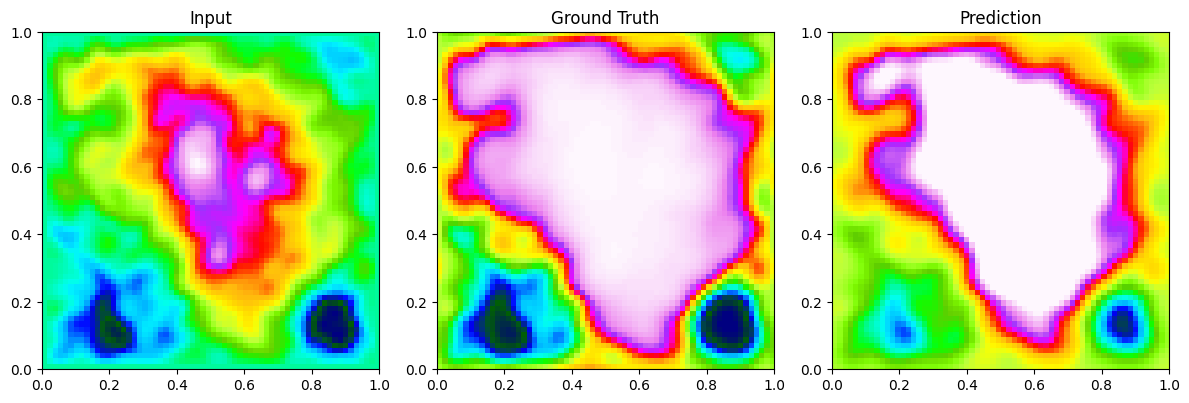

In [ ]:
########################
# Plot results:
########################
model.eval()
with torch.no_grad():
    input, output = next(iter(val_loader))

    # Reshape for graph model
    batch_size = input.shape[0]
    input_nodes = input.reshape(batch_size, 64*64, 1)
    pred_nodes = model(input_nodes, edge_index)
    pred = pred_nodes.reshape(batch_size, 1, 64, 64)

    # Convert to numpy for visualization
    input = input[0,0].numpy()
    output = output[0,0].numpy()
    pred = pred[0,0].detach().numpy()

vmin = np.min(output)
vmax = np.max(output)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(input, cmap = "gist_ncar", extent=(0,1,0,1),)
axes[0].set_title("Input")
axes[1].imshow(output, cmap = "gist_ncar", extent=(0,1,0,1), vmin = vmin, vmax= vmax)
axes[1].set_title("Ground Truth")
axes[2].imshow(pred, cmap = "gist_ncar", extent=(0,1,0,1), vmin = vmin, vmax= vmax)
axes[2].set_title("Prediction")
plt.tight_layout()
plt.show()

## Tasks

Each task requires you to change a few lines of code. After each change, run the training again and compare:
- **Train Loss**
- **Rel L1 Test Norm**

**Task 1 — Compare GCN vs GAT**  
Goal: See how different graph layers affect the result.  
Change `model_name = "gat"` to `model_name = "gcn"`.  
Run once with `"gat"` and once with `"gcn"` and compare the validation error.

**Task 2 — Change the number of message passing layers**  
Goal: Understand what “deeper GNN” means.  
In the config, try `self.n_layers = 2` (then try `4`, then `6`).  
Observe how performance changes as you increase the number of layers.

**Task 3 — Change the graph connectivity**  
Goal: Understand how `edge_index` defines *who communicates with whom*.